In [3]:
#These are libraries that you should import if needed for your notebook.
#import libraries
import pandas as pd
import seaborn as sns
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
from google.colab import files

**Correlation** measures the strength and direction of the relationship between
two numerical variables.

* **Positive correlation**: as one variable increases, the other tends to increase.
* **Negative correlation**: as one variable increases, the other tends to decrease.
* **No correlation**: there is no clear linear relationship between the variables.

Correlation is commonly measured using the correlation coefficient, \(r\), which ranges from −1 to +1:

* \(r $\approx$ +1\): strong positive relationship
* \(r $\approx$ 0\): little or no linear relationship
* \(r $\approx$ -1\): strong negative relationship

For example, hours studied and exam score may have a positive correlation, while speed and travel time for a fixed distance may have a negative correlation.

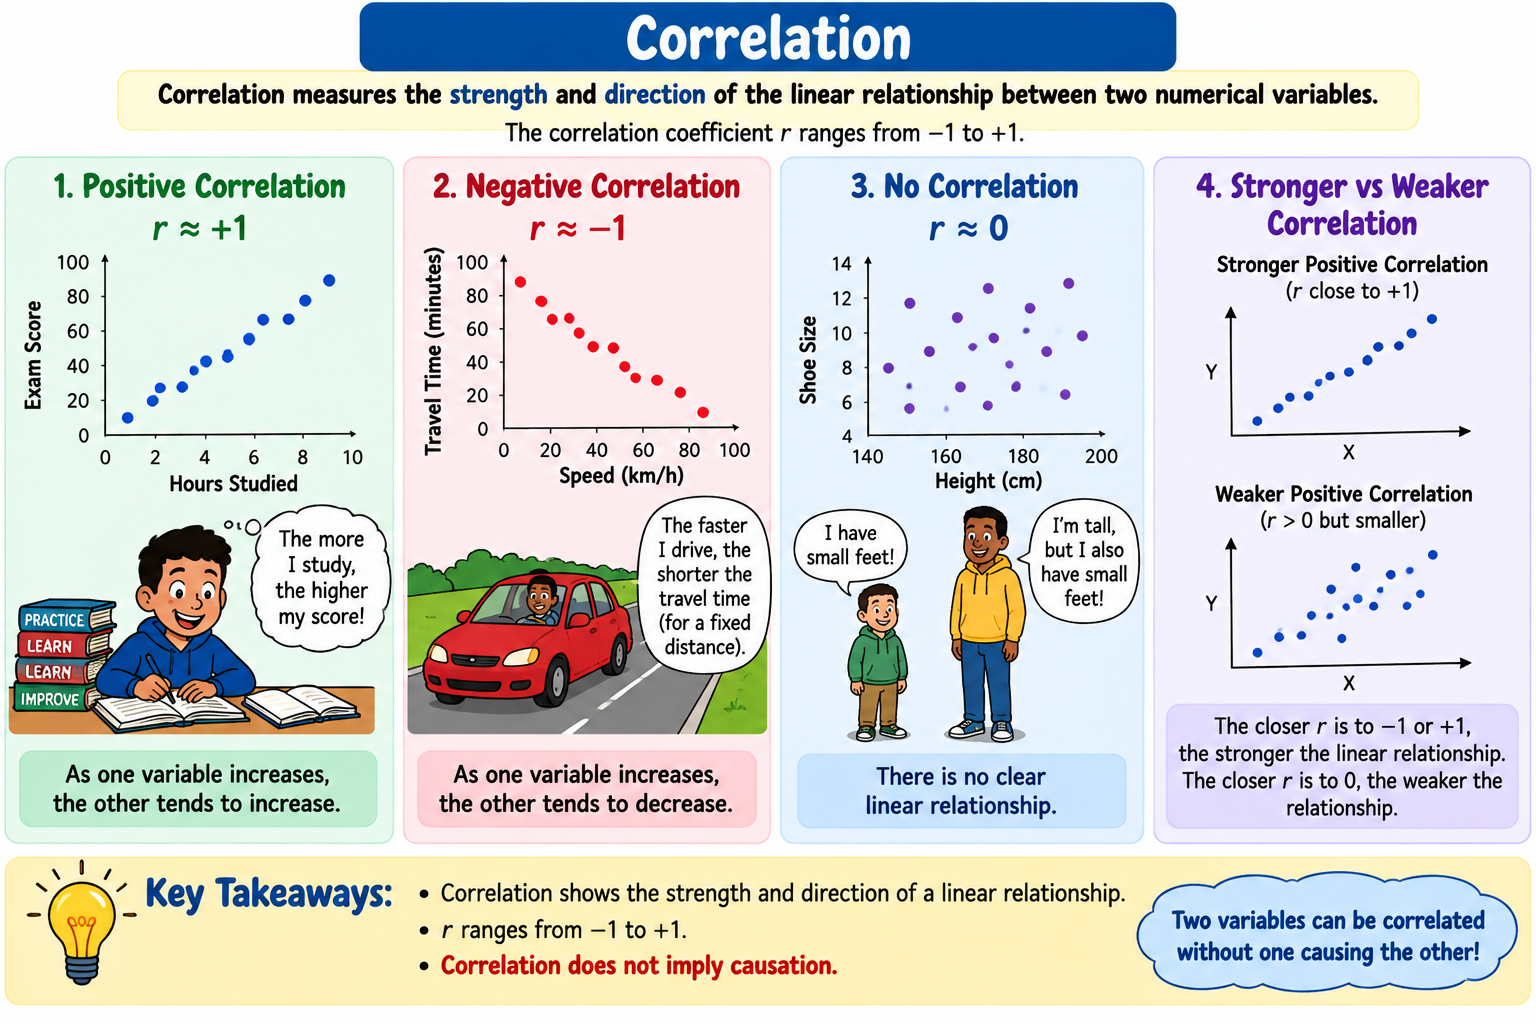

**Correlation shows association, but it does not prove that one variable causes the other.**

In [4]:
def r_scatter(r):
    plots.figure(figsize=(5,5))
    "Generate a scatter plot with a correlation approximately r"
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    plots.scatter(x, y, color='darkblue', s=20)
    plots.xlim(-4, 4)
    plots.ylim(-4, 4)

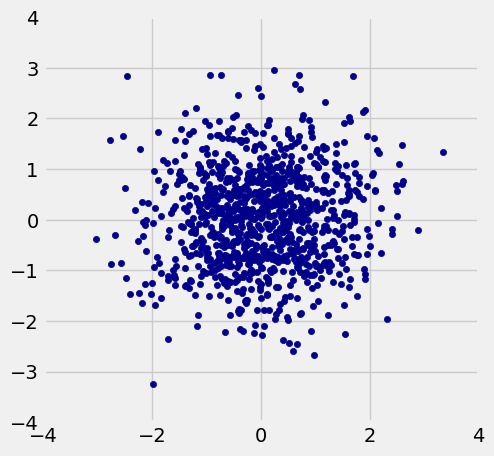

In [8]:
r_scatter(0.078)

## Approach to Prediction

* **Correlation** and **Prediction** are closely related because correlation helps us identify whether two variables move together in a consistent way. When a strong relationship exists, information about one variable can be used to help predict the value of the other.

* For example, if hours studied and exam scores are positively correlated, we may use the number of hours studied to predict a student's expected exam score.

* **Correlation identifies the relationship; prediction uses that relationship to estimate unknown or future values.**

However, a strong correlation does not guarantee perfect predictions and does not necessarily mean that one variable causes the other.

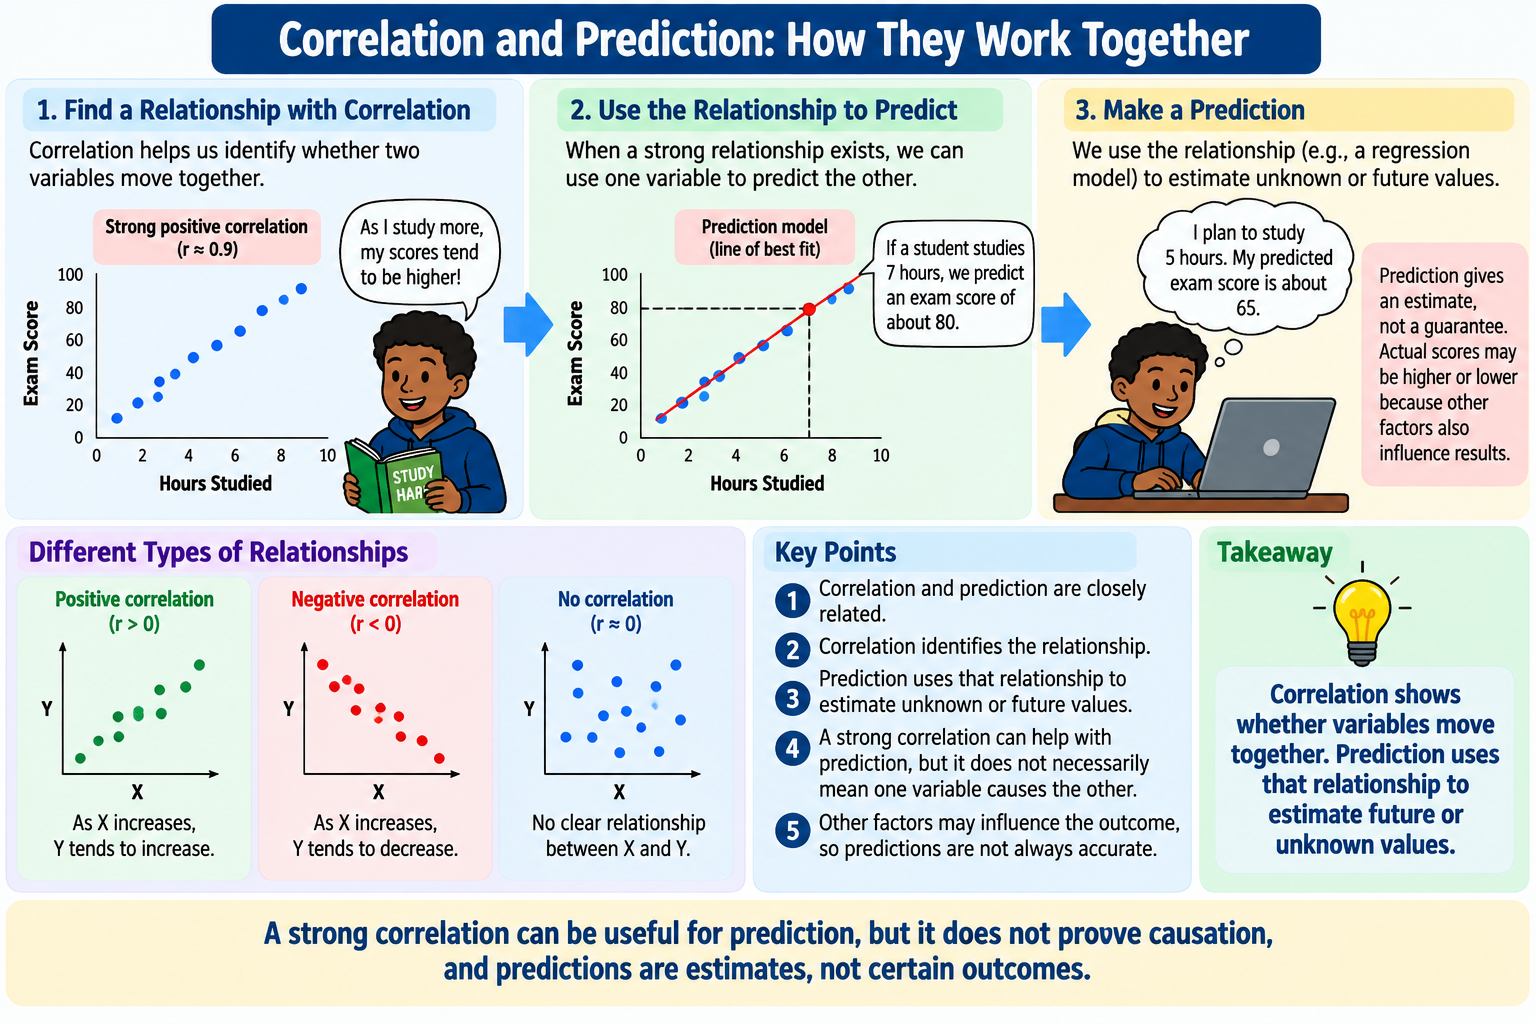

In [ ]:
#upload the file family_height.csv   # Note: Child heights are the **adult** heights of children in a family
uploaded=files.upload()

Saving family_heights.csv to family_heights.csv


In [ ]:
#Read the file family_heights.csv
families=pd.read_csv('family_heights.csv')

In [ ]:
families

,family,father,mother,child,children,order,sex
0,1,78.5,67.0,73.2,4,1,male
1,1,78.5,67.0,69.2,4,2,female
2,1,78.5,67.0,69.0,4,3,female
3,1,78.5,67.0,69.0,4,4,female
4,2,75.5,66.5,73.5,4,1,male
...,...,...,...,...,...,...,...
929,203,62.0,66.0,64.0,3,1,male
930,203,62.0,66.0,62.0,3,2,female
931,203,62.0,66.0,61.0,3,3,female
932,204,62.5,63.0,66.5,2,1,male


In [ ]:
# Avrage height of the parents
parent_avgs = (families['father'] + families['mother'])/2
parent_avgs

,0
0,72.75
1,72.75
2,72.75
3,72.75
4,71.00
...,...
929,64.00
930,64.00
931,64.00
932,62.75


In [ ]:
# CReate a new table called heights with a column titled 'Parent Average' with values of the array parent_avgs and also another column "Child" with values from the families table's column 'child'
heights = pd.DataFrame()
heights['Parent Average'] = parent_avgs
heights['Child'] = families['child']
heights


,Parent Average,Child
0,72.75,73.2
1,72.75,69.2
2,72.75,69.0
3,72.75,69.0
4,71.00,73.5
...,...,...
929,64.00,64.0
930,64.00,62.0
931,64.00,61.0
932,62.75,66.5


Text(0, 0.5, 'Child')

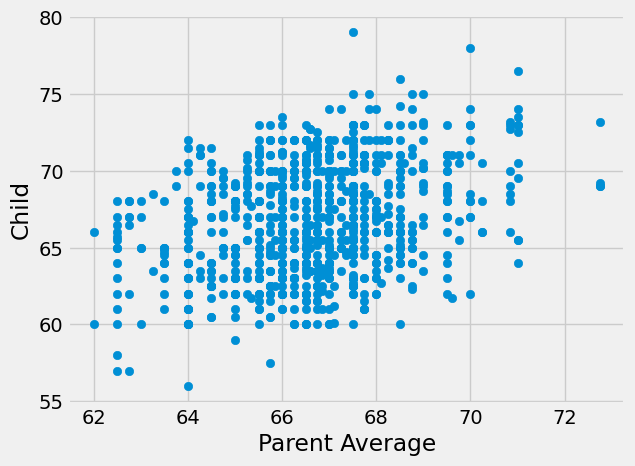

In [ ]:
# PLot a Scatter plot with child on the y-axis and parent_avg on the y-axis
plots.scatter(heights['Parent Average'], heights['Child'])
plots.xlabel('Parent Average')
plots.ylabel('Child')

Text(0, 0.5, 'Child')

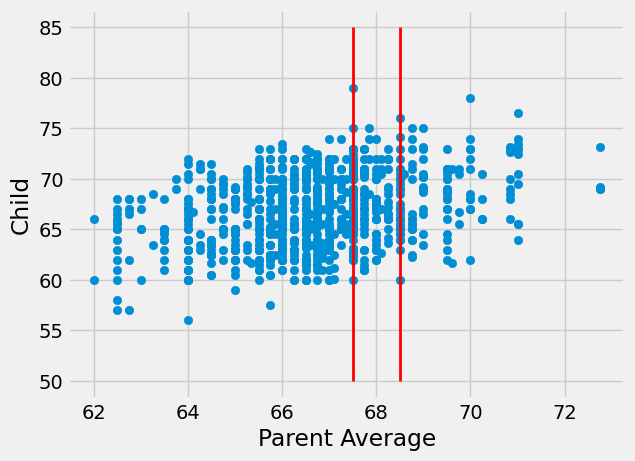

In [ ]:
plots.scatter(heights['Parent Average'], heights['Child'])
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2);
plots.xlabel('Parent Average')
plots.ylabel('Child')

In [ ]:

# Extract all the points where Paverent Average is between 67.5 and 68.5
nearby = heights.query('67.5 <= `Parent Average` <= 68.5')
nearby_mean = np.average(nearby['Child'])


nearby


,Parent Average,Child
33,68.0,74.0
34,68.0,70.0
35,68.0,68.0
36,68.0,67.0
37,68.0,67.0
...,...,...
581,67.5,68.0
582,67.5,68.0
583,67.5,68.0
584,67.5,66.2


In [ ]:
nearby_mean

67.6140909090909

Text(0, 0.5, 'Child')

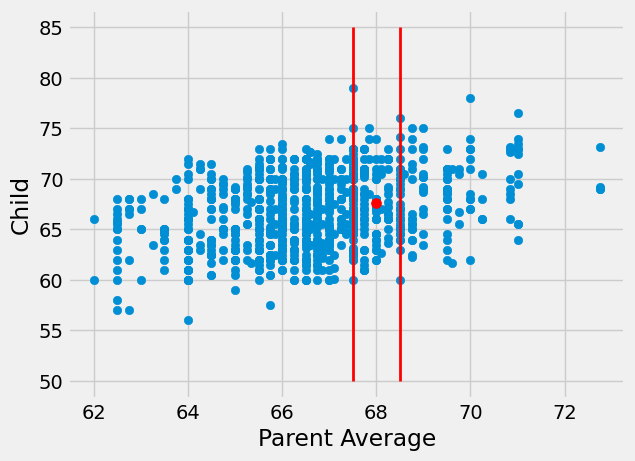

In [ ]:
plots.scatter(heights['Parent Average'], heights['Child'])
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2)
plots.scatter(68, nearby_mean, color='red', s=50);
plots.xlabel('Parent Average')
plots.ylabel('Child')

In [ ]:
def predict_child(h):
    """Predict the height of a child whose parents have a parent average height of p_avg.

    The prediction is the average height of the children whose parent average height is
    in the range p_avg plus or minus 0.5.
    """
    # Filter rows where 'Parent Average' is within the specified range
    nearby = heights[(heights['Parent Average'] >= h - 0.5) & (heights['Parent Average'] <= h + 0.5)]

    # Calculate the average height of the 'Child' column
    return np.average(nearby['Child'])

In [ ]:
# Assuming `heights` is a DataFrame and 'Parent Average' is an existing column
heights['Prediction'] = heights['Parent Average'].apply(predict_child)
heights

,Parent Average,Child,Prediction
0,72.75,73.2,70.100000
1,72.75,69.2,70.100000
2,72.75,69.0,70.100000
3,72.75,69.0,70.100000
4,71.00,73.5,70.415789
...,...,...,...
929,64.00,64.0,65.080682
930,64.00,62.0,65.080682
931,64.00,61.0,65.080682
932,62.75,66.5,64.351724


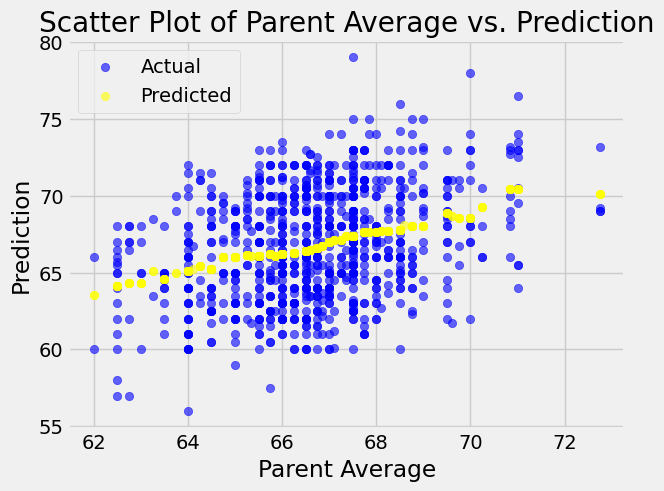

In [ ]:
# Scatter plot of 'Parent Average' vs 'Prediction'
# Scatter plot of 'Parent Average' vs 'Prediction'

plots.scatter(heights['Parent Average'], heights['Child'], color='blue', alpha=0.6)

# Line plot of 'Parent Average' vs 'Prediction'
plots.scatter(heights['Parent Average'], heights['Prediction'], color='yellow', alpha=0.6)

# Adding labels and title
plots.xlabel('Parent Average')
plots.ylabel('Prediction')
plots.title('Scatter Plot of Parent Average vs. Prediction')
plots.legend(['Actual', 'Predicted'])
# Display the plot
plots.show()